In [1]:
import sys
from pathlib import Path

project_src = str(Path("..").resolve() / "src")
if project_src not in sys.path:
    sys.path.insert(0, project_src)

for module_name in list(sys.modules):
    if module_name == "pysse" or module_name.startswith("pysse."):
        del sys.modules[module_name]

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pysse import ElectricFieldPulse, SSE

In [2]:
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [3]:
intensity = 1E4  # Intensity in W/cm^2
fwhm = 1000  # FWHM in as
omega_x = 277  # Pulse oscillation frequency in eV
omega_o = 8.13947
dt = 5E-3  # Finer time step for smoother TDSE propagation

field_x = ElectricFieldPulse(intensity=intensity, dt=dt, pulse_type='gaussian_sin', fwhm=fwhm, omega_sin=omega_x, time_span=800)
field_o = ElectricFieldPulse(intensity=intensity, dt=dt, pulse_type='gaussian_sin', fwhm=fwhm, omega_sin=omega_o, time_span=800)

electric_field = {"time": field_x.time, "pulse_x": field_o.pulse, "pulse_y": field_x.pulse, "pulse_z": np.zeros_like(field_x.pulse)}

In [4]:
print(field_x)
print(field_o)

Electric Field Pulse:
  Intensity: 10000.0 W/cm^2
  FWHM: 1000 as
  Central frequency: 10.179557097393005 a.u.
  E_max: 5.337605126836238e-07 a.u.
  Sigma: 17.556064814293702 a.u.
  Time step (dt): 0.005 a.u.
  Number of steps: 160000
  Pulse type: gaussian_sin
  Time at maximum: 88.0 a.u.
  Energy window: None a.u.
  Pulse width: None a.u.

Electric Field Pulse:
  Intensity: 10000.0 W/cm^2
  FWHM: 1000 as
  Central frequency: 0.2991198541787633 a.u.
  E_max: 5.337605126836238e-07 a.u.
  Sigma: 17.556064814293702 a.u.
  Time step (dt): 0.005 a.u.
  Number of steps: 160000
  Pulse type: gaussian_sin
  Time at maximum: 88.0 a.u.
  Energy window: None a.u.
  Pulse width: None a.u.



In [5]:
propagation_method = "RK4"

Text(0.5, 1.0, 'FFT of Sinusoidal Gaussian Pulse X-rays')

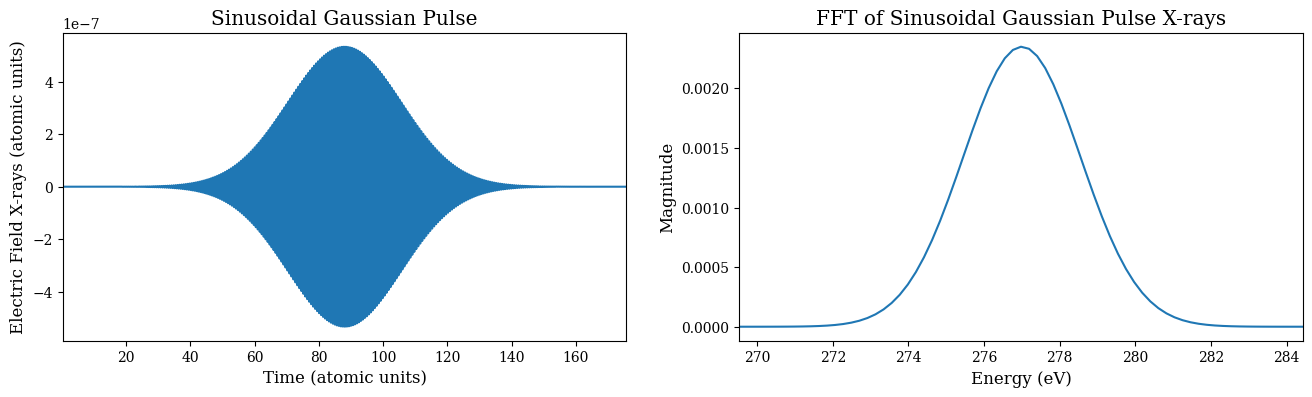

In [6]:
plt.figure(figsize=(16,4))

plt.subplot(1,2,1)
plt.plot(field_x.time, field_x.pulse, label='Carbon')
plt.xlabel('Time (atomic units)')
plt.ylabel('Electric Field X-rays (atomic units)')
plt.xlim(field_x.time_limits)
plt.title('Sinusoidal Gaussian Pulse')

plt.subplot(1,2,2)
plt.plot(field_x.freq, field_x.magnitude)
plt.xlim(field_x.freq_limits)
plt.xlabel('Energy (eV)')
plt.ylabel('Magnitude')
plt.title('FFT of Sinusoidal Gaussian Pulse X-rays')

Text(0.5, 1.0, 'FFT of Sinusoidal Gaussian Pulse Optical')

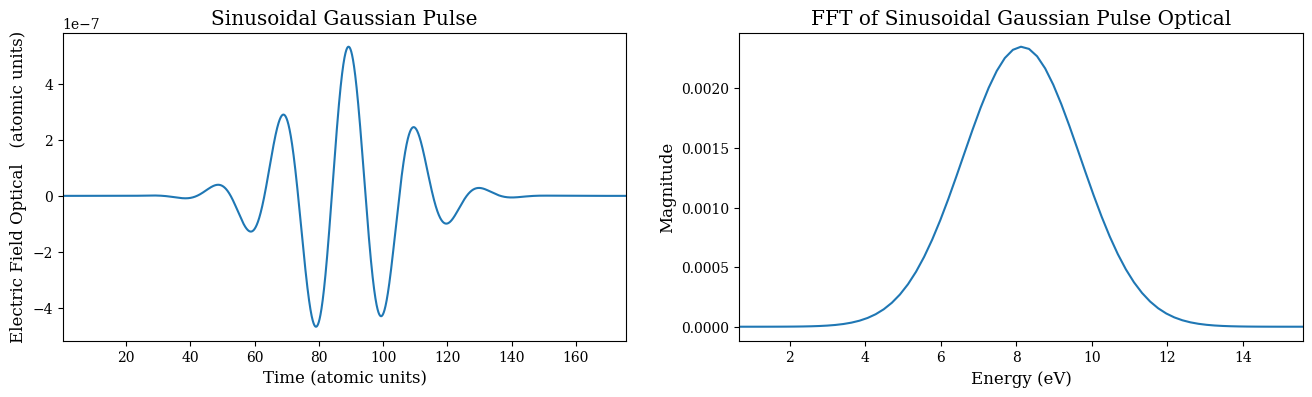

In [7]:
plt.figure(figsize=(16,4))

plt.subplot(1,2,1)
plt.plot(field_o.time, field_o.pulse, label='Carbon')
plt.xlabel('Time (atomic units)')
plt.ylabel('Electric Field Optical   (atomic units)')
plt.xlim(field_o.time_limits)
plt.title('Sinusoidal Gaussian Pulse')

plt.subplot(1,2,2)
plt.plot(field_o.freq, field_o.magnitude)
plt.xlim(field_o.freq_limits)
plt.xlabel('Energy (eV)')
plt.ylabel('Magnitude')
plt.title('FFT of Sinusoidal Gaussian Pulse Optical')

In [8]:
initial_conditions = np.array([
    [0,1.0]
])

In [9]:
sse = SSE("../data_minimal/dummy_data/", electric_field, initial_conditions, propagation_method)

In [10]:
population = sse.population
total_population = population[:, 0] + population[:, 1] + population[:, 2]

In [11]:
print(population[:, 2])

[0.00000000e+00 5.22890260e-36 4.70373882e-35 ... 3.40347771e-15
 3.40347771e-15 3.40347770e-15]


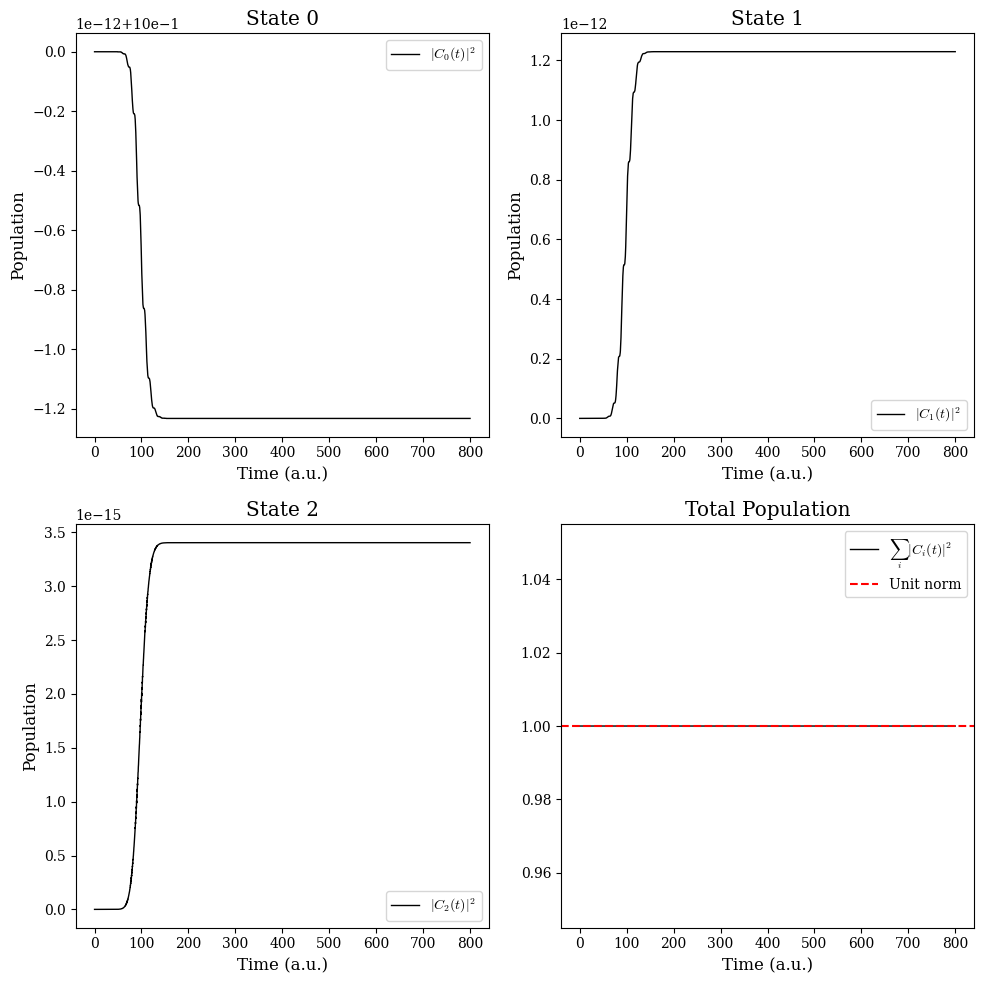

In [12]:
plot_stride = max(1, len(sse.time) // 5000)
plot_time = sse.time[::plot_stride]
plot_population = population[::plot_stride]
plot_total = total_population[::plot_stride]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, state in zip(axes.flat[:3], range(3)):
    ax.plot(plot_time, plot_population[:, state], label=rf"$|C_{state}(t)|^2$", color="black", linewidth=1.0)
    ax.set_title(f"State {state}")
    ax.set_xlabel("Time (a.u.)")
    ax.set_ylabel("Population")
    ax.legend()

axes[1, 1].plot(plot_time, plot_total, label=r"$\sum_i |C_i(t)|^2$", color="black", linewidth=1.0)
axes[1, 1].axhline(1, color="red", linestyle="--", label="Unit norm")
axes[1, 1].set_title("Total Population")
axes[1, 1].set_xlabel("Time (a.u.)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

/Users/manuelfernandosanchezalarcon/Desktop/Trieste_Project/Chemistry/sfg_dfg/pysse_env/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/manuelfernandosanchezalarcon/Desktop/Trieste_Project/Chemistry/sfg_dfg/pysse_env/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


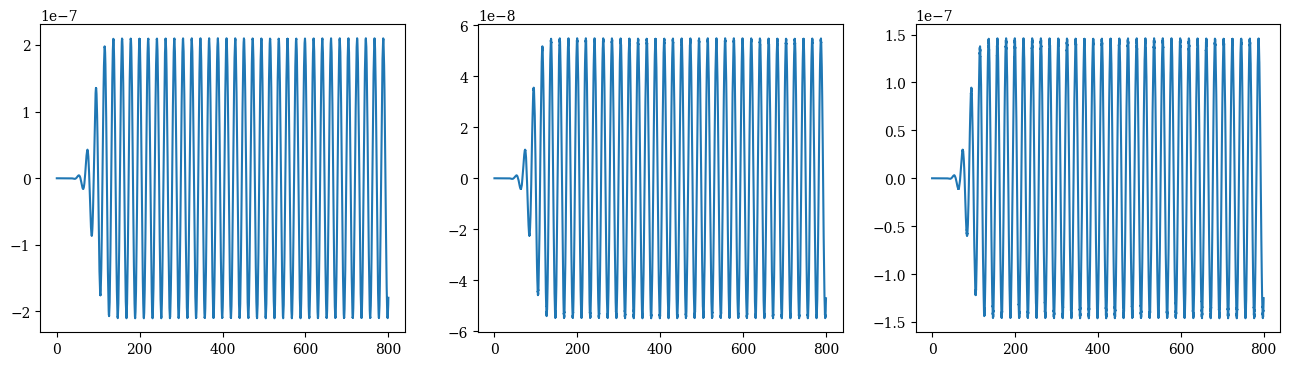

In [13]:
plt.figure(figsize=(16,4))

plt.subplot(1,3,1)
plt.plot(sse.time, sse.mu_t[0])
plt.subplot(1,3,2)
plt.plot(sse.time, sse.mu_t[1])
plt.subplot(1,3,3)
plt.plot(sse.time, sse.mu_t[2])
plt.show()

In [14]:
def fft_pulse(time, pulse) -> None:
    """Compute and store the FFT-based pulse spectrum.
    Stores
    ------
    freq : numpy.ndarray
        Frequency axis in eV.
    magnitude : numpy.ndarray
        Absolute FFT magnitude of the pulse.
    """
    conversion_factor_hartree_to_ev = 27.2114
    dt = time[1] - time[0]
    n_points = len(time)
    freq = np.fft.fftfreq(n_points, d=dt)
    pulse_fft = np.fft.fft(pulse)
    pulse_fft = np.fft.fftshift(pulse_fft)
    freq = np.fft.fftshift(freq)
    freq = 2 * np.pi * freq * conversion_factor_hartree_to_ev
    magnitude = np.abs(pulse_fft)
    return freq, pulse_fft

In [15]:
fft_mu_x, mu_x_fft = fft_pulse(sse.time, sse.mu_t[0])
fft_mu_y, mu_y_fft = fft_pulse(sse.time, sse.mu_t[1])
fft_mu_z, mu_z_fft = fft_pulse(sse.time, sse.mu_t[2])

mask = fft_mu_x > 100

fft_mu_x = fft_mu_x[mask]
mu_x_fft = mu_x_fft[mask]

fft_mu_y = fft_mu_y[mask]
mu_y_fft = mu_y_fft[mask]

fft_mu_z = fft_mu_z[mask]
mu_z_fft = mu_z_fft[mask]

plt.figure(figsize=(16,4))

plt.subplot(1,3,1)
plt.plot(fft_mu_x, np.abs(mu_x_fft))
plt.xlim(272, 280)
plt.subplot(1,3,2)
plt.plot(fft_mu_y, np.abs(mu_y_fft))
plt.xlim(272, 280)
plt.subplot(1,3,3)
plt.plot(fft_mu_z, np.abs(mu_z_fft))
plt.xlim(272, 280)
plt.show()



KeyboardInterrupt: 